# Vom Ort zur datenbasierten Aussage

Dieses Notebook zeigt nicht nur Ergebnisse, sondern den Weg zu den Daten:
von der Fragestellung über Metadaten und Dateistrukturen bis zu Auswertungen und Visualisierungen.

Ausgangspunkt ist nicht das Werkzeug, sondern eine Frage.

## Fragestellung

Beispielfrage:
Wie hat sich der Niederschlag an einem Ort entwickelt und wie häufig treten Starkregentage auf?

Dazu müssen passende und verlässliche Realdaten zunächst gefunden, geprüft und aufbereitet werden.

## Überblick über den Datenweg

1. Datenquelle und Metadaten betrachten
2. Eine geeignete Station zum Ort finden
3. Verfügbare Dateien (historische und aktuelle Niederschlagsdaten) prüfen
4. Daten laden und aufbereiten
5. Optional: Export in Excel
6. Auswerten und visualisieren

In [3]:
ORT = "Hannover"

## Technische Vorbereitung

Die folgenden Hilfsfunktionen übernehmen technische Schritte wie das Laden von Text- und ZIP-Dateien.
Sie dienen der Infrastruktur und stehen nicht im Zentrum der inhaltlichen Untersuchung.

In [4]:
import io
import re
import zipfile
import requests
import certifi
import pandas as pd
import matplotlib.pyplot as plt

## 1. Datenquelle und Metadaten

Realdaten liegen nicht als fertige Tabelle vor.
Zunächst werden daher Metadaten zur Wetterstation eingelesen.
Diese enthalten unter anderem Stationsnummern, Stationsnamen und Zeiträume.


In [5]:
# Basisadressen für historische und aktuelle Niederschlagsdaten des DWD
BASE_HIST = "https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/more_precip/historical/"
BASE_REC  = "https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/more_precip/recent/"

def get_text(url: str) -> str:
    r = requests.get(url, verify=certifi.where(), timeout=30)
    r.raise_for_status()
    return r.text

stations_url = BASE_HIST + "RR_Tageswerte_Beschreibung_Stationen.txt"
stations_text = get_text(stations_url)

stations = pd.read_fwf(
    io.StringIO(stations_text),
    skiprows=2,
    names=[
        "STATIONS_ID", "VON_DATUM", "BIS_DATUM", "STATIONSHOEHE",
        "GEOBREITE", "GEOLAENGE", "STATIONSNAME", "BUNDESLAND", "ABGABE"
    ]
)

stations["STATIONS_ID"] = stations["STATIONS_ID"].astype(str).str.zfill(5)
display(stations.head())


,STATIONS_ID,VON_DATUM,BIS_DATUM,STATIONSHOEHE,GEOBREITE,GEOLAENGE,STATIONSNAME,BUNDESLAND,ABGABE
0,00001,19120101,19860630,478,47.8413,8.8493,Aach,Baden-Württemberg,Frei
1,00002,19510101,20061231,138,50.8066,6.0996,Aachen (Kläranlage),Nordrhein-Westfalen,Frei
2,00003,18910101,20110331,202,50.7827,6.0941,Aachen,Nordrhein-Westfalen,Frei
3,00004,19510101,19791031,243,50.7683,6.1207,Aachen-Brand,Nordrhein-Westfalen,Frei
4,00006,19821101,20260403,455,48.8361,10.0598,Aalen-Unterrombach,Baden-Württemberg,Frei


## 2. Eine Station zum Ort finden

Ein Ort ist noch kein Datensatz.
Zunächst wird geprüft, welche Stationen überhaupt zum gewählten Ort passen.
Schon hier zeigt sich, dass mehrere Stationen mit unterschiedlichen Zeiträumen existieren können.

In [6]:
stations_ort = stations[stations["STATIONSNAME"].str.contains(ORT, case=False, na=False)].copy()
stations_ort[["STATIONS_ID", "STATIONSNAME", "VON_DATUM", "BIS_DATUM"]]

,STATIONS_ID,STATIONSNAME,VON_DATUM,BIS_DATUM
1816,02007,Hannover (Eilenriede),19510101,19810930
1817,02008,Hannover (Stadt),19870101,19910731
1818,02009,Hannover-Bornum,19870101,19951231
1819,02010,Hannover-Bothfeld,19780101,19810930
1820,02011,Hannover-Herrenhausen,19310101,20260403
1821,02012,Hannover-Kirchrode,19610101,20260403
1822,02013,Hannover-Königsworther Straße,19310101,19601230
1823,02014,Hannover,19360101,20260403
1824,02015,Hannover-Messegelände,19610101,20051231
1825,02016,Hannover-Misburg,19870101,19950630


## 3. Welche Dateien gibt es wirklich?

Eine Station in der Metadatenliste ist noch keine gesicherte Datenbasis.
Deshalb wird nun geprüft, ob zu den gefundenen Stationen tatsächlich Dateien vorhanden sind.

Dabei ist besonders wichtig, ob sowohl historische als auch aktuelle Daten verfügbar sind.

In [7]:
def files_for_station(station_id: str, files: list[str]) -> list[str]:
    return [f for f in files if f"_{station_id}_" in f]

hist_html = get_text(BASE_HIST)
rec_html = get_text(BASE_REC)

hist_files = sorted(set(re.findall(r'tageswerte_RR_\d{5}_\d{8}_\d{8}_hist\.zip', hist_html)))
rec_files = sorted(set(re.findall(r'tageswerte_RR_\d{5}_akt\.zip', rec_html)))

for sid in stations_ort["STATIONS_ID"]:
    hist_match = files_for_station(sid, hist_files)
    rec_match = files_for_station(sid, rec_files)

    print("\nStation:", sid)
    print("historical:", hist_match)
    print("recent    :", rec_match)


Station: 02007
historical: ['tageswerte_RR_02007_19510101_19810930_hist.zip']
recent    : []

Station: 02008
historical: ['tageswerte_RR_02008_19870101_19910731_hist.zip']
recent    : []

Station: 02009
historical: ['tageswerte_RR_02009_19870101_19951231_hist.zip']
recent    : []

Station: 02010
historical: ['tageswerte_RR_02010_19780101_19810930_hist.zip']
recent    : []

Station: 02011
historical: ['tageswerte_RR_02011_19310101_20241231_hist.zip']
recent    : ['tageswerte_RR_02011_akt.zip']

Station: 02012
historical: ['tageswerte_RR_02012_19610101_20241231_hist.zip']
recent    : ['tageswerte_RR_02012_akt.zip']

Station: 02013
historical: ['tageswerte_RR_02013_19310101_19601230_hist.zip']
recent    : []

Station: 02014
historical: ['tageswerte_RR_02014_19360101_20241231_hist.zip']
recent    : ['tageswerte_RR_02014_akt.zip']

Station: 02015
historical: ['tageswerte_RR_02015_19610101_20051231_hist.zip']
recent    : []

Station: 02016
historical: ['tageswerte_RR_02016_19870101_19950630

## 4. Eine geeignete Station auswählen

Für eine längere Untersuchung ist eine Station besonders hilfreich, wenn sowohl historische als auch aktuelle Daten verfügbar sind.
Deshalb wird nun eine Station ausgewählt, für die beide Dateitypen vorliegen.

In [8]:
auswahl = None

for _, row in stations_ort.iterrows():
    sid = row["STATIONS_ID"]
    hist_match = files_for_station(sid, hist_files)
    rec_match = files_for_station(sid, rec_files)

    if hist_match and rec_match:
        auswahl = row
        break

if auswahl is None:
    raise ValueError(
        f"Für den Ort {ORT} wurde keine Station mit historischen und aktuellen Daten gefunden."
    )

STATION_ID = auswahl["STATIONS_ID"]

stations_ort[stations_ort["STATIONS_ID"] == STATION_ID][
    ["STATIONS_ID", "STATIONSNAME", "VON_DATUM", "BIS_DATUM"]
]

,STATIONS_ID,STATIONSNAME,VON_DATUM,BIS_DATUM
1820,02011,Hannover-Herrenhausen,19310101,20260403


Die Auswahl erfolgt hier nicht nur nach dem Ortsnamen, sondern nach der tatsächlichen Verfügbarkeit der Dateien.
Damit wird sichtbar: Eine passende Station muss nicht nur existieren, sondern auch eine tragfähige Datenbasis für die Untersuchung liefern.

## 5. Welche Dateien werden verwendet?

Nach der Auswahl der Station wird nun bestimmt, welche konkrete historische und welche aktuelle Datei zu dieser Station gehören.
Erst damit ist klar, auf welche Datenbasis sich die weitere Untersuchung stützt.

In [9]:
hist_ort = files_for_station(STATION_ID, hist_files)
rec_ort = files_for_station(STATION_ID, rec_files)

if not hist_ort:
    raise ValueError(f"Keine historische Datei für Station {STATION_ID} gefunden.")

hist_file = hist_ort[0]
hist_url = BASE_HIST + hist_file

if rec_ort:
    rec_file = rec_ort[0]
    rec_url = BASE_REC + rec_file
else:
    rec_file = None
    rec_url = None

print("Historische Datei:", hist_file)
print("Aktuelle Datei   :", rec_file)

Historische Datei: tageswerte_RR_02011_19310101_20241231_hist.zip
Aktuelle Datei   : tageswerte_RR_02011_akt.zip


## 6. Aus einer Archivdatei wird ein Datensatz

Die ausgewählten Dateien liegen als ZIP-Archive vor.
Eine solche Datei ist noch keine direkt auswertbare Tabelle.

Deshalb müssen nun die eigentlichen Messdaten innerhalb des Archivs gefunden, eingelesen und in eine bearbeitbare Form überführt werden.

In [10]:
# Funktion zum Laden einer Datei als Bytefolge:
# Anders als get_text() wird hier nicht Text, sondern der rohe Dateiinhalt zurückgegeben.
# Das ist nötig, weil ZIP-Dateien binär übertragen werden.
def get_bytes(url: str) -> bytes:
    r = requests.get(url, verify=certifi.where(), timeout=30)
    r.raise_for_status()
    return r.content

def load_rr_zip(url: str) -> pd.DataFrame:
    zip_bytes = get_bytes(url)

    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        txt_name = [
            n for n in zf.namelist()
            if n.startswith("produkt_") and n.endswith(".txt")
        ][0]

        with zf.open(txt_name) as f:
            df = pd.read_csv(f, sep=";", na_values=["-999", "-999.0"])

    df.columns = df.columns.str.strip()
    df["MESS_DATUM"] = pd.to_datetime(df["MESS_DATUM"], format="%Y%m%d")
    df["RS"] = pd.to_numeric(df["RS"], errors="coerce")

    df = df[["STATIONS_ID", "MESS_DATUM", "RS"]].copy()
    df = df.rename(columns={"MESS_DATUM": "datum", "RS": "niederschlag_mm"})
    df = df.dropna(subset=["niederschlag_mm"])

    return df

## 7. Historische und aktuelle Daten zusammenführen

Für die ausgewählte Station werden nun die historischen und aktuellen Daten geladen.
Anschließend werden beide Bestände zu einer gemeinsamen Tabelle zusammengeführt.

In [11]:
hist_df = load_rr_zip(hist_url)

if rec_url is not None:
    rec_df = load_rr_zip(rec_url)
    combined = pd.concat([hist_df, rec_df], ignore_index=True)
else:
    combined = hist_df.copy()

combined = combined.drop_duplicates(subset=["STATIONS_ID", "datum"])
combined = combined.sort_values("datum").reset_index(drop=True)

display(combined.head())
display(combined.tail())

print("Gesamtzeitraum:", combined["datum"].min(), "bis", combined["datum"].max())

,STATIONS_ID,datum,niederschlag_mm
0,2011,1931-01-01,6.5
1,2011,1931-01-02,0.0
2,2011,1931-01-03,5.8
3,2011,1931-01-04,0.8
4,2011,1931-01-05,4.2


,STATIONS_ID,datum,niederschlag_mm
34778,2011,2026-03-30,1.2
34779,2011,2026-03-31,0.0
34780,2011,2026-04-01,0.0
34781,2011,2026-04-02,0.0
34782,2011,2026-04-03,1.3


Gesamtzeitraum: 1931-01-01 00:00:00 bis 2026-04-03 00:00:00


Jetzt liegt erstmals ein bearbeitbarer Datensatz vor.
Er ist nicht einfach „gefunden“ worden, sondern das Ergebnis mehrerer Schritte:
Stationswahl, Dateiprüfung, Laden der Archivdateien, Bereinigung und Zusammenführung.

Erst auf dieser Grundlage können systematische Berechnungen und Visualisierungen folgen.

**Hinweis:** Der Datensatz kann anschließend auch in eine Excel-Datei exportiert werden.
Gerade in einem vertrauten Excel-Umfeld wird sichtbar, welche Vorarbeit nötig ist, damit Realdaten überhaupt rechnerisch bearbeitbar werden.

## 8. Zeitinformationen ergänzen

Der Datensatz enthält bisher Tageswerte mit Datum.
Für weitere Auswertungen werden nun Jahr, Monat und Tag als eigene Spalten ergänzt.

Zusätzlich wird erfasst, an welchen Tagen mindestens 20 mm Niederschlag gefallen sind.
Solche Tage werden hier als Starkregentage gezählt.

## 8. Zeitinformationen ergänzen

Der Datensatz enthält bisher Tageswerte mit Datum.
Für weitere Auswertungen werden nun Jahr, Monat und Tag als eigene Spalten ergänzt.

Zusätzlich wird erfasst, an welchen Tagen mindestens 20 mm Niederschlag gefallen sind.
Solche Tage werden hier als Starkregentage gezählt.

In [12]:
combined["jahr"] = combined["datum"].dt.year
combined["monat"] = combined["datum"].dt.month
combined["tag"] = combined["datum"].dt.day

combined["starkregen_20mm"] = combined["niederschlag_mm"] >= 20

display(combined.head())

,STATIONS_ID,datum,niederschlag_mm,jahr,monat,tag,starkregen_20mm
0,2011,1931-01-01,6.5,1931,1,1,False
1,2011,1931-01-02,0.0,1931,1,2,False
2,2011,1931-01-03,5.8,1931,1,3,False
3,2011,1931-01-04,0.8,1931,1,4,False
4,2011,1931-01-05,4.2,1931,1,5,False


## 9. Aus Tagesdaten werden untersuchbare Größen

Erst jetzt lassen sich aus den täglichen Messwerten weiterführende Größen bilden,
zum Beispiel Monatssummen, Jahressummen oder die Anzahl von Starkregentagen pro Jahr.

In [13]:
monatssumme = combined.groupby(["jahr", "monat"], as_index=False)["niederschlag_mm"].sum()

jahressumme = combined.groupby("jahr", as_index=False)["niederschlag_mm"].sum()

starkregen_pro_jahr = combined.groupby("jahr", as_index=False)["starkregen_20mm"].sum()
starkregen_pro_jahr = starkregen_pro_jahr.rename(
    columns={"starkregen_20mm": "anzahl_starkregentage_20mm"}
)

display(monatssumme.head())
display(jahressumme.head())
display(starkregen_pro_jahr.head())

,jahr,monat,niederschlag_mm
0,1931,1,67.2
1,1931,2,30.7
2,1931,3,11.5
3,1931,4,68.9
4,1931,5,30.1


,jahr,niederschlag_mm
0,1931,743.8
1,1932,532.4
2,1933,578.6
3,1934,460.6
4,1935,662.8


,jahr,anzahl_starkregentage_20mm
0,1931,7
1,1932,2
2,1933,5
3,1934,0
4,1935,3


## 10. Vollständige Jahre bestimmen

Für Jahresvergleiche ist es hilfreich, nur solche Jahre zu berücksichtigen,
für die Daten aus allen zwölf Monaten vorliegen.

Gerade an dieser Stelle zeigt sich ein typisches Merkmal von Realdaten:
Nicht jeder formal vorhandene Zeitraum ist für jede Auswertung gleichermaßen geeignet.

In [14]:
monate_pro_jahr = combined.groupby("jahr")["monat"].nunique().reset_index(name="anzahl_monate")

vollstaendige_jahre = monate_pro_jahr[monate_pro_jahr["anzahl_monate"] == 12]["jahr"]

jahressumme_voll = jahressumme[jahressumme["jahr"].isin(vollstaendige_jahre)].copy()
starkregen_voll = starkregen_pro_jahr[starkregen_pro_jahr["jahr"].isin(vollstaendige_jahre)].copy()

print("Die letzten vollständigen Jahre:")
print(vollstaendige_jahre.tolist()[-10:])

jahr_auswahl = 2026
vorhandene_monate = sorted(combined.loc[combined["jahr"] == jahr_auswahl, "monat"].unique())

print(f"Vorhandene Monate im Jahr {jahr_auswahl}: {vorhandene_monate}")

Die letzten vollständigen Jahre:
[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Vorhandene Monate im Jahr 2026: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


## 11. Optional: Export nach Excel

Der aufbereitete Datensatz kann nun auch nach Excel exportiert werden.
Gerade in einem vertrauten Excel-Umfeld wird sichtbar, welche Vorarbeit nötig ist,
damit Realdaten überhaupt rechnerisch bearbeitbar werden.

Python ersetzt Excel hier nicht grundsätzlich.
Es hilft vielmehr, die aufwendigen und wiederkehrenden Schritte der Aufbereitung
zu automatisieren und in einer stabilen Form bereitzustellen.

Die aufbereiteten Daten können zusätzlich nach Excel exportiert werden.
Dadurch werden die Ergebnisse sichtbar, weiterverwendbar und reproduzierbar.

In Excel können auf dieser Grundlage auch eigene Tabellen, Berechnungen und Grafiken erzeugt werden.

In [15]:
tagesdaten_export = combined[
    ["STATIONS_ID", "datum", "jahr", "monat", "tag", "niederschlag_mm", "starkregen_20mm"]
].copy()

dateiname = f"../excel/niederschlag_tagesdaten_{ORT.replace(' ', '_')}.xlsx"
tagesdaten_export.to_excel(dateiname, index=False)

print("Exportiert:", dateiname)

stations_export = stations_ort[stations_ort["STATIONS_ID"] == STATION_ID].copy()

dateiname = f"../excel/niederschlag_auswertung_{ORT.replace(' ', '_')}.xlsx"
with pd.ExcelWriter(dateiname) as writer:
    tagesdaten_export.to_excel(writer, sheet_name="Tagesdaten_bereinigt", index=False)
    monatssumme.to_excel(writer, sheet_name="Monatssummen", index=False)
    jahressumme_voll.to_excel(writer, sheet_name="Jahressummen", index=False)
    starkregen_voll.to_excel(writer, sheet_name="Starkregentage", index=False)
    stations_export.to_excel(writer, sheet_name="Ausgewaehlte_Station", index=False)

print("Exportiert:", dateiname)

Exportiert: ../excel/niederschlag_tagesdaten_Hannover.xlsx
Exportiert: ../excel/niederschlag_auswertung_Hannover.xlsx


### Bis jetzt ...
- Fragestellung
- Datenquelle und Metadaten
- Station zum Ort finden
- Verfügbare Dateien prüfen
- Geeignete Station auswählen
- Konkrete Dateien bestimmen
- Aus Archivdateien wird ein Datensatz
- Zeitinformationen ergänzen
- Zentrale Aggregationen berechnen
- Vollständige Jahre bestimmen
- Optional: Export nach Excel

## 12. Jahresniederschlag

Die folgende Darstellung zeigt den Jahresniederschlag für alle vollständigen Jahre.
Sie entsteht erst auf der Grundlage der zuvor ausgewählten, bereinigten und zusammengeführten Daten.

Die folgenden Darstellungen können angezeigt und bei Bedarf zusätzlich als PDF gespeichert werden.


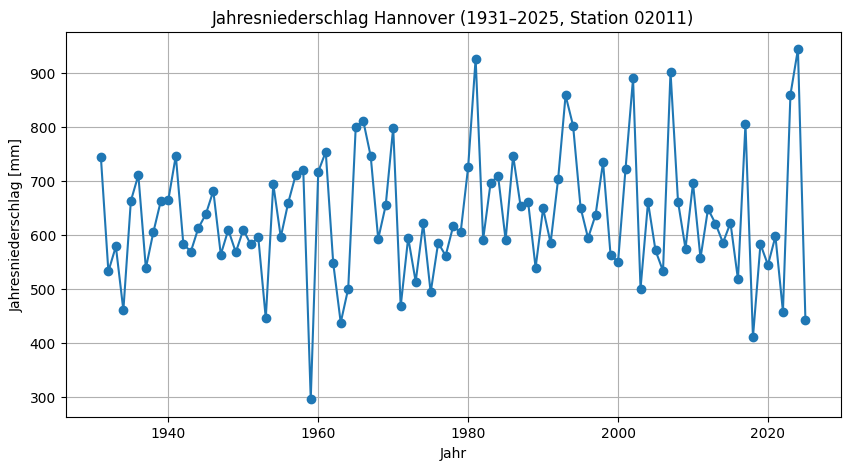

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(jahressumme_voll["jahr"], jahressumme_voll["niederschlag_mm"], marker="o")

start_jahr = jahressumme_voll["jahr"].min()
end_jahr = jahressumme_voll["jahr"].max()

plt.xlabel("Jahr")
plt.ylabel("Jahresniederschlag [mm]")
plt.title(f"Jahresniederschlag {ORT} ({start_jahr}–{end_jahr}, Station {STATION_ID})")
plt.grid(True)

plt.show()

## 13. Monatsverlauf ausgewählter Jahre

Aus dem aufbereiteten Datensatz lassen sich nun auch ausgewählte Jahre miteinander vergleichen.
So wird sichtbar, dass dieselbe Datenbasis unterschiedliche Perspektiven auf den Niederschlag eröffnet.

,jahr,monat,niederschlag_mm
0,1960,1,56.8
1,1960,2,31.9
2,1960,3,15.6
3,1960,4,41.7
4,1960,5,79.6
5,1960,6,24.2
6,1960,7,48.7
7,1960,8,135.4
8,1960,9,24.8
9,1960,10,100.9


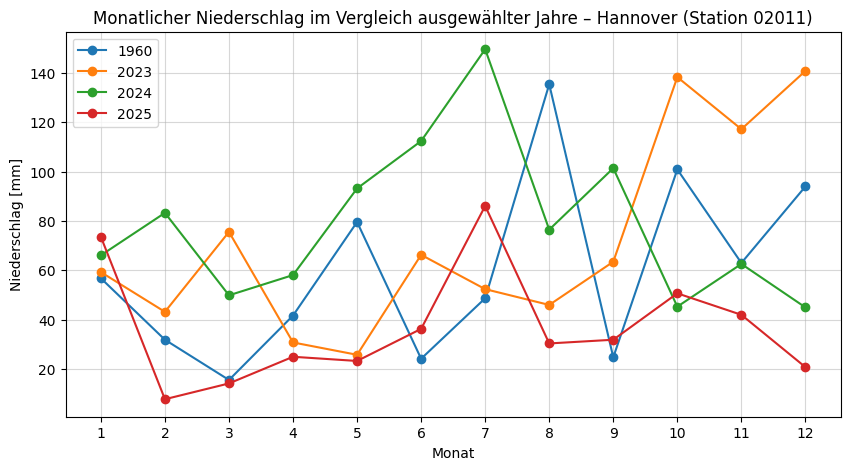

In [17]:
# Jahre festlegen, die miteinander verglichen werden sollen
jahre_vergleich = [1960, 2023, 2024, 2025]

# Plot- und Speicheroptionen festlegen
plot_anzeigen = True
plot_speichern = False

# Für die ausgewählten Jahre die monatlichen Niederschlagssummen berechnen
vergleich = combined[combined["jahr"].isin(jahre_vergleich)].groupby(
    ["jahr", "monat"], as_index=False
)["niederschlag_mm"].sum()

# Vergleichstabelle zur Kontrolle anzeigen
display(vergleich.head(15))

# Diagramm nur erzeugen, wenn es angezeigt oder gespeichert werden soll
if plot_anzeigen or plot_speichern:
    plt.figure(figsize=(10, 5))

    # Für jedes ausgewählte Jahr eine eigene Linie zeichnen
    for jahr in jahre_vergleich:
        daten = vergleich[vergleich["jahr"] == jahr]
        plt.plot(daten["monat"], daten["niederschlag_mm"], marker="o", label=str(jahr))

    # Achsen beschriften
    plt.xlabel("Monat")
    plt.ylabel("Niederschlag [mm]")

    # Titel dynamisch aus Ort und Stations-ID erzeugen
    plt.title(f"Monatlicher Niederschlag im Vergleich ausgewählter Jahre – {ORT} (Station {STATION_ID})")

    # Monatszahlen auf der x-Achse anzeigen
    plt.xticks(range(1, 13))

    # Gitternetz und Legende einblenden
    plt.grid(True, alpha=0.5)
    plt.legend()

    # Grafik optional als PDF-Datei speichern
    if plot_speichern:
        pdf_datei = f"../fig/jahresvergleich_monatsniederschlag_{ORT.replace(' ', '_')}.pdf"
        plt.savefig(pdf_datei, format="pdf", bbox_inches="tight")

    # Grafik optional anzeigen
    if plot_anzeigen:
        plt.show()
    else:
        plt.close()

## 14. Starkregentage pro Jahr

Neben Jahressummen kann auch untersucht werden, in wie vielen Tagen eines Jahres mindestens 20 mm Niederschlag gefallen sind.
Damit wird eine zweite Perspektive auf denselben Datensatz sichtbar.

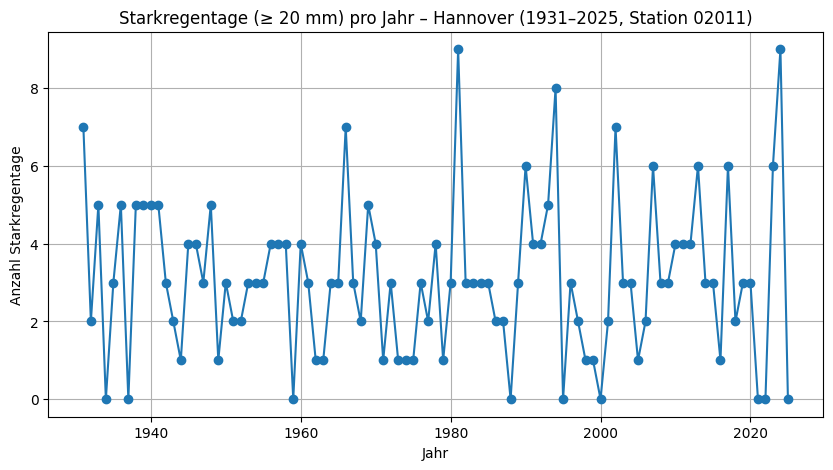

In [18]:
# Starkregentage nur für vollständige Jahre bis zum gewählten Endjahr übernehmen
endjahr_plot = starkregen_voll["jahr"].max()
starkregen_plot = starkregen_voll[starkregen_voll["jahr"] <= endjahr_plot].copy()

# Plot- und Speicheroptionen festlegen
plot_anzeigen = True
plot_speichern = True

# Diagramm nur erzeugen, wenn es angezeigt oder gespeichert werden soll
if plot_anzeigen or plot_speichern:
    plt.figure(figsize=(10, 5))
    plt.plot(starkregen_plot["jahr"], starkregen_plot["anzahl_starkregentage_20mm"], marker="o")

    # Achsen beschriften
    plt.xlabel("Jahr")
    plt.ylabel("Anzahl Starkregentage")

    # Start- und Endjahr des tatsächlich dargestellten Zeitraums bestimmen
    start_jahr = starkregen_plot["jahr"].min()
    end_jahr = starkregen_plot["jahr"].max()

    # Titel dynamisch aus Schwellenwert, Ort, Zeitraum und Stations-ID erzeugen
    plt.title(
        f"Starkregentage (≥ 20 mm) pro Jahr – {ORT} "
        f"({start_jahr}–{end_jahr}, Station {STATION_ID})"
    )

    # Gitternetz einblenden
    plt.grid(True)

    # Grafik optional als PDF-Datei speichern
    if plot_speichern:
        pdf_datei = f"../fig/starkregentage_{ORT.replace(' ', '_')}_bis_{end_jahr}.pdf"
        plt.savefig(pdf_datei, format="pdf", bbox_inches="tight")

    # Grafik optional anzeigen
    if plot_anzeigen:
        plt.show()
    else:
        plt.close()

## 15. Rückblick

Bevor die erste Grafik entstehen konnte, waren mehrere Schritte notwendig:
- eine Forschungsfrage präzisieren,
- eine verlässliche Quelle wählen,
- Metadaten lesen,
- eine geeignete Station identifizieren,
- verfügbare Dateien prüfen,
- Daten laden, bereinigen und zusammenführen,
- erst danach Berechnungen und Visualisierungen erstellen.

Gerade darin zeigt sich ein wichtiger Unterschied zwischen Realdaten und bereits aufbereiteten Unterrichtstabellen:
Der Datensatz liegt nicht einfach vor, sondern muss zunächst erschlossen werden.

Python steht dabei nicht im Zentrum als Selbstzweck.
Es hilft vielmehr, die komplexen und wiederkehrenden Schritte der Verarbeitung transparent und reproduzierbar zu automatisieren.
Auch der Export nach Excel kann sinnvoll sein, weil dort in einer vertrauten Umgebung sichtbar wird,
welche Vorarbeit nötig ist, damit Realdaten überhaupt rechnerisch bearbeitbar werden.

## 16. Realität und Modell: zwei Beispiele

Bis hierhin wurden reale Niederschlagsdaten erschlossen, geprüft, aufbereitet und ausgewertet.

Im nächsten Schritt geht es nicht mehr nur um die Beschreibung der vorliegenden Daten,
sondern um zwei einfache Modellideen:

- Wie entwickelt sich die **Anzahl der Rekorde** im Verlauf der Jahre?
- Wie häufig treten **Anstiege gegenüber dem Vorjahr** auf?

Beide Fragen führen von der reinen Datenbetrachtung zu einem ersten Vergleich zwischen
**beobachteter Realität** und **mathematischem Modell**.

Dabei geht es ausdrücklich nicht darum, die Wirklichkeit vollständig zu erklären.
Vielmehr sollen an überschaubaren Beispielen typische Unterschiede zwischen
Datenbefund und Modellannahme sichtbar werden.

## 17. Modellbeispiel 1: Anzahl der Rekorde

Ein Jahr liefert genau einen Jahresniederschlag.
Ordnet man die Jahre chronologisch, dann ist ein Wert genau dann ein **Rekord**,
wenn er größer ist als alle vorherigen Werte.

Schon in einer völlig zufälligen Folge ist zu erwarten, dass es anfangs mehrere Rekorde gibt,
später aber immer seltener neue Höchstwerte auftreten.
Der Grund ist einfach:
Mit jedem weiteren Jahr wächst die Hürde, einen bisherigen Maximalwert noch zu übertreffen.

Gerade deshalb ist die Anzahl der Rekorde ein interessantes Beispiel für den Vergleich von
**Realität** und **Modell**:
Einerseits lässt sie sich direkt aus den Daten bestimmen,
andererseits gibt es dafür auch ein einfaches probabilistisches Grundmodell.

Hier wird also nicht nur gezählt, **wie viele Rekorde tatsächlich auftreten**,
sondern auch gefragt, **ob diese Anzahl ungefähr zu einer zufälligen Entwicklung passt**
oder ob sich deutliche Abweichungen zeigen.

In [19]:
jahresmax_voll = (
    combined.groupby("jahr")
    .agg(
        jahresmaximum_mm=("niederschlag_mm", "max"),
        anzahl_monate=("monat", "nunique")
    )
    .reset_index()
)

jahresmax_voll = jahresmax_voll[jahresmax_voll["anzahl_monate"] == 12].copy()

display(jahresmax_voll.head())
display(jahresmax_voll.tail())

print("Zeitraum:", jahresmax_voll["jahr"].min(), "bis", jahresmax_voll["jahr"].max())

,jahr,jahresmaximum_mm,anzahl_monate
0,1931,33.4,12
1,1932,23.6,12
2,1933,51.2,12
3,1934,19.2,12
4,1935,28.5,12


,jahr,jahresmaximum_mm,anzahl_monate
90,2021,18.0,12
91,2022,15.8,12
92,2023,50.5,12
93,2024,41.9,12
94,2025,19.7,12


Zeitraum: 1931 bis 2025


In [20]:
combined["jahr"] = combined["datum"].dt.year
combined["monat"] = combined["datum"].dt.month

In [21]:
combined["datum"] = pd.to_datetime(combined["datum"], format="%Y-%m-%d", errors="coerce")
combined["jahr"] = combined["datum"].dt.year
combined["monat"] = combined["datum"].dt.month

jahresmax_voll = (
    combined.groupby("jahr")
    .agg(
        jahresmaximum_mm=("niederschlag_mm", "max"),
        anzahl_monate=("monat", "nunique")
    )
    .reset_index()
)

jahresmax_voll = jahresmax_voll[jahresmax_voll["anzahl_monate"] == 12].copy()

display(jahresmax_voll.head())
display(jahresmax_voll.tail())

print("Zeitraum:", jahresmax_voll["jahr"].min(), "bis", jahresmax_voll["jahr"].max())

,jahr,jahresmaximum_mm,anzahl_monate
0,1931,33.4,12
1,1932,23.6,12
2,1933,51.2,12
3,1934,19.2,12
4,1935,28.5,12


,jahr,jahresmaximum_mm,anzahl_monate
90,2021,18.0,12
91,2022,15.8,12
92,2023,50.5,12
93,2024,41.9,12
94,2025,19.7,12


Zeitraum: 1931 bis 2025


In [22]:
jahresmax_voll = jahresmax_voll.sort_values("jahr").reset_index(drop=True)

jahresmax_voll["rekordjahr"] = jahresmax_voll["jahresmaximum_mm"].gt(
    jahresmax_voll["jahresmaximum_mm"].cummax().shift(fill_value=-1)
)

display(jahresmax_voll[jahresmax_voll["rekordjahr"]])
print("Anzahl Rekordjahre:", int(jahresmax_voll["rekordjahr"].sum()))

,jahr,jahresmaximum_mm,anzahl_monate,rekordjahr
0,1931,33.4,12,True
2,1933,51.2,12,True
5,1936,55.1,12,True
8,1939,58.5,12,True
23,1954,61.2,12,True
71,2002,83.6,12,True
79,2010,85.2,12,True


Anzahl Rekordjahre: 7


In [23]:
# Excel-Datei mit Jahresmaxima exportieren
export_df = jahresmax_voll[["jahr", "jahresmaximum_mm", "rekordjahr"]].copy()
export_df["rekordjahr"] = export_df["rekordjahr"].map({True: "ja", False: ""})

dateiname = "../excel/jahresmaxima_hannover_herrenhausen.xlsx"
export_df.to_excel(dateiname, index=False)

print("Exportiert:", dateiname)
display(export_df.head(15))
display(export_df.tail(15))

Exportiert: ../excel/jahresmaxima_hannover_herrenhausen.xlsx


,jahr,jahresmaximum_mm,rekordjahr
0,1931,33.4,ja
1,1932,23.6,
2,1933,51.2,ja
3,1934,19.2,
4,1935,28.5,
5,1936,55.1,ja
6,1937,17.6,
7,1938,47.2,
8,1939,58.5,ja
9,1940,33.5,


,jahr,jahresmaximum_mm,rekordjahr
80,2011,31.5,
81,2012,26.7,
82,2013,37.0,
83,2014,23.7,
84,2015,25.5,
85,2016,31.8,
86,2017,33.1,
87,2018,28.8,
88,2019,40.7,
89,2020,26.2,


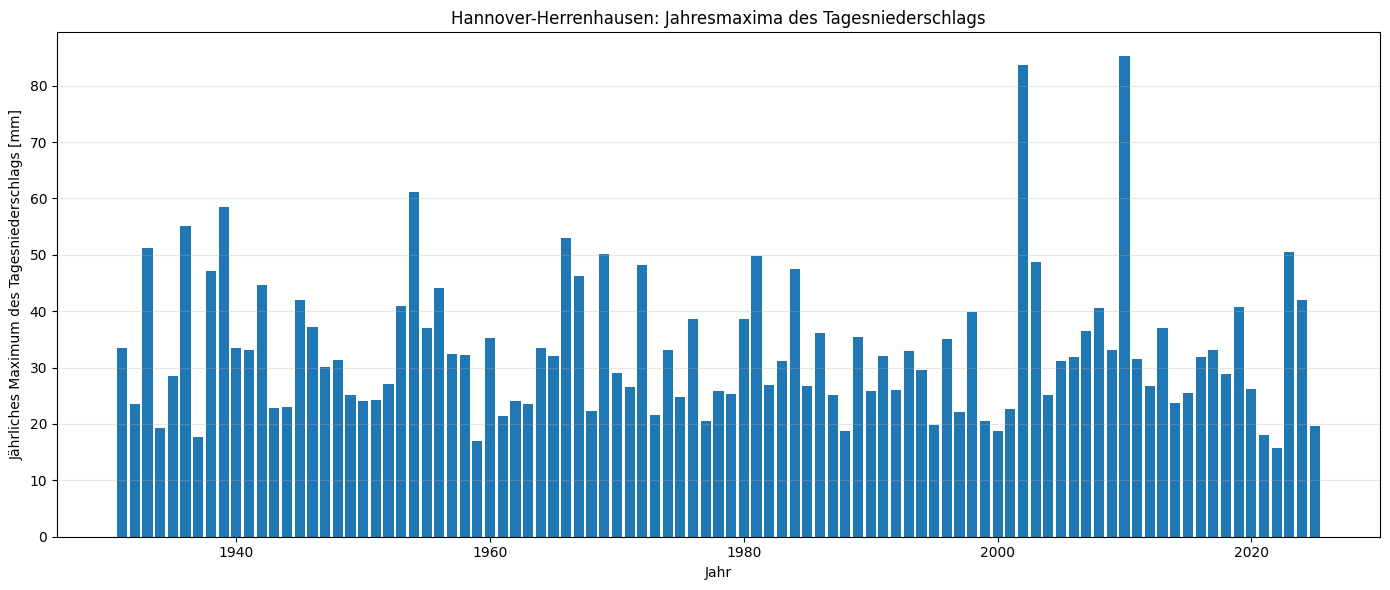

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.bar(jahresmax_voll["jahr"], jahresmax_voll["jahresmaximum_mm"])

plt.xlabel("Jahr")
plt.ylabel("Jährliches Maximum des Tagesniederschlags [mm]")
plt.title("Hannover-Herrenhausen: Jahresmaxima des Tagesniederschlags")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

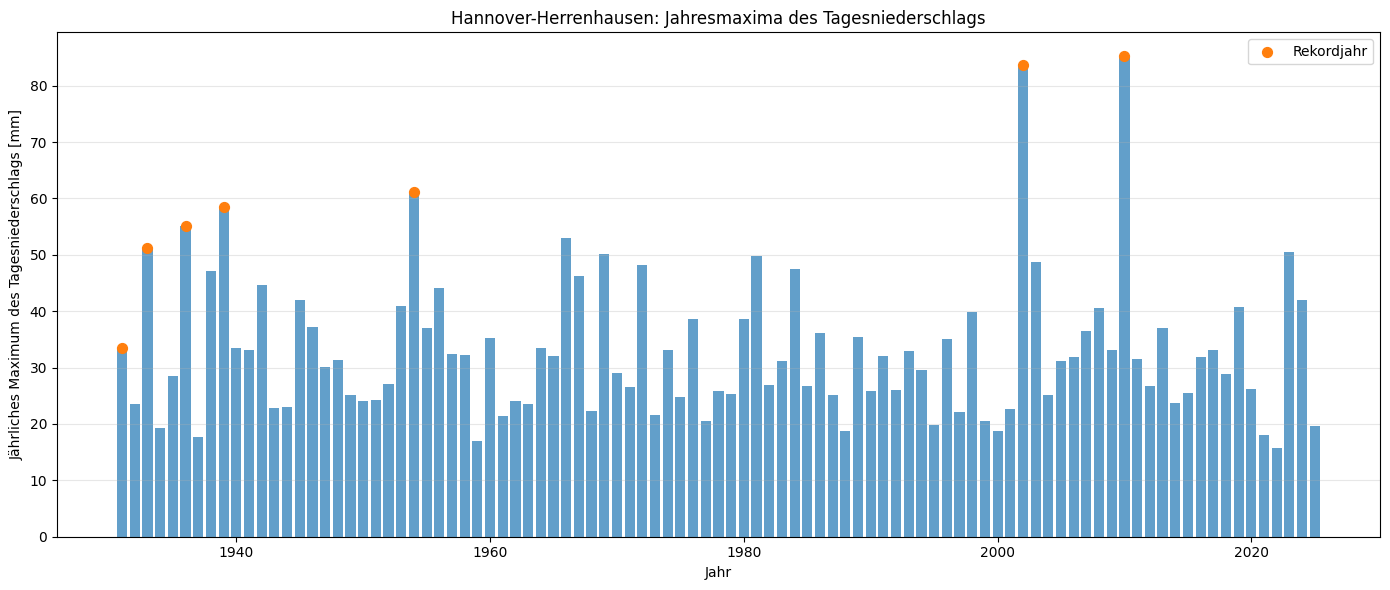

In [25]:
plt.figure(figsize=(14, 6))
plt.bar(jahresmax_voll["jahr"], jahresmax_voll["jahresmaximum_mm"], alpha=0.7)

rekorde = jahresmax_voll[jahresmax_voll["rekordjahr"]]
plt.scatter(
    rekorde["jahr"],
    rekorde["jahresmaximum_mm"],
    s=50,
    zorder=3,
    label="Rekordjahr"
)

plt.xlabel("Jahr")
plt.ylabel("Jährliches Maximum des Tagesniederschlags [mm]")
plt.title("Hannover-Herrenhausen: Jahresmaxima des Tagesniederschlags")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 18. Modellbeispiel 2: Anzahl der Anstiege

Nun wird eine andere, noch einfachere Frage betrachtet:
In wie vielen Jahren ist der Jahresniederschlag **größer als im jeweiligen Vorjahr**?

Damit wird nicht nach Rekorden gefragt, sondern nur nach dem unmittelbaren Vergleich
zweier aufeinanderfolgender Jahre.
Jeder solche Vergleich hat zwei Richtungen:
Der Wert steigt oder er sinkt.

Unter einer sehr einfachen Modellannahme ohne systematischen Trend wäre zu erwarten,
dass beide Möglichkeiten ungefähr gleich häufig auftreten.
Gerade deshalb eignet sich die **Anzahl der Anstiege** gut als zweites Modellbeispiel.

Auch hier steht nicht eine fertige Erklärung im Mittelpunkt.
Wichtiger ist der Gedanke, dass reale Daten zunächst beobachtet werden
und anschließend gefragt wird, welches einfache Modell als Vergleich dienen kann
– und an welcher Stelle die Wirklichkeit möglicherweise von diesem Modell abweicht.

In [26]:
jahresmax_voll = jahresmax_voll.sort_values("jahr").reset_index(drop=True)

jahresmax_voll["anstieg"] = jahresmax_voll["jahresmaximum_mm"].diff() > 0

anzahl_anstiege = int(jahresmax_voll["anstieg"].sum())
n = len(jahresmax_voll)
erwartung = (n - 1) / 2

display(jahresmax_voll[["jahr", "jahresmaximum_mm", "anstieg"]].head(15))
print("Anzahl der Jahre:", n)
print("Beobachtete Anzahl der Anstiege:", anzahl_anstiege)
print("Erwartete Anzahl im einfachen Zufallsmodell:", erwartung)

,jahr,jahresmaximum_mm,anstieg
0,1931,33.4,False
1,1932,23.6,False
2,1933,51.2,True
3,1934,19.2,False
4,1935,28.5,True
5,1936,55.1,True
6,1937,17.6,False
7,1938,47.2,True
8,1939,58.5,True
9,1940,33.5,False


Anzahl der Jahre: 95
Beobachtete Anzahl der Anstiege: 46
Erwartete Anzahl im einfachen Zufallsmodell: 47.0
